Utilizzando il database Best_Cancer replicare l'esercitazione
- Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y
- Effettuare la standarizzazione di train e test set
- Ridurre il dataset con PCA a n_components=2
- Allenare un K-Means con parametri di default
- Creare una griglia di parametri e avviare una ricerca dei parametri migliori per  un clusetring con KMeans
- Effettaure le predizioni per entrambi i modelli allenati
- Calcolare la silhouette score per entrambi i modelli
- Stampare silhouette score e parametri di entrambi i modelli
- Subplottare i cluster dei dati reali (ridotti con PCA) in base al colore e i relativi centroidi, si aper il modello di default che per quello tuned

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Utilizzando il database Best_Cancer replicare l'esercitazione

In [2]:
data=load_breast_cancer()
X=data.data
y=data.target

feature_names=data.feature_names

- Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y

In [4]:
X_train, X_test, y_train, y_test=train_test_split(X,y,shuffle=True,stratify=y,test_size=0.2,random_state=42)

- Effettuare la standarizzazione di train e test set

In [5]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

- Ridurre il dataset con PCA a n_components=2

In [6]:
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

- Allenare un K-Means con parametri di default

In [11]:
kmeans_default=KMeans(random_state=42)
kmeans_default.fit(X_train_pca)


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


- Creare una griglia di parametri e avviare una ricerca dei parametri migliori per  un clusetring con KMeans

In [12]:
param_grid={"n_clusters":[2,3,4,5],"init":["k-means++","random"],"n_init":[10,20]}

In [22]:
kmeans_best=None
best_params=None
silhouette_best=-1 #peggiore, metrica per isolare quanto ogni singolo cluster è coeso all'interno e separato dagli altri cluster

for n_clusters in param_grid["n_clusters"]:
    for init in param_grid["init"]:
        for n_init in param_grid["n_init"]:
            kmeans=KMeans(init=init,n_clusters=n_clusters, n_init=n_init,random_state=42)
            labels=kmeans.fit_predict(X_train_pca)
            score=silhouette_score(X_train_pca,labels)
            if score>silhouette_best:
                silhouette_best=score
                best_params={"init":init,"n_init":n_init,"n_clusters":n_clusters}
                kmeans_best=kmeans

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

- Calcolare la silhouette score per entrambi i modelli

In [25]:
y_test_pred_default = kmeans_default.predict(X_test_pca)
silhouette_default = silhouette_score(X_test_pca, y_test_pred_default)
y_test_pred_tuned = kmeans_best.predict(X_test_pca)
silhouette_tuned = silhouette_score(X_test_pca, y_test_pred_default)

- Stampare silhouette score e parametri di entrambi i modelli

In [27]:
print(f"Parametri Default:\n{kmeans_default.get_params()}")
print(f"Migliori Parametri:\n{best_params}")
print(f"Silhouette (default):\t{silhouette_default:.2f}")
print(f"Silhouette (tuned):\t{silhouette_best:.2f}")

Parametri Default:
{'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 8, 'n_init': 'auto', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}
Migliori Parametri:
{'init': 'k-means++', 'n_init': 10, 'n_clusters': 2}
Silhouette (default):	0.29
Silhouette (tuned):	0.52


In [28]:
print(f"Migliori parametri:\n{best_params}")
print(f"Silhouette (default):\t{silhouette_default}")
print(f"Silhouette (best/tunned):\t{silhouette_best}")

Migliori parametri:
{'init': 'k-means++', 'n_init': 10, 'n_clusters': 2}
Silhouette (default):	0.29314423252195454
Silhouette (best/tunned):	0.5185519866061751


- Subplottare i cluster dei dati reali (ridotti con PCA) in base al colore e i relativi centroidi, si aper il modello di default che per quello tuned

In [30]:
def plot_clusters(ax,X,labels,model, title):
   h = 0.02
   x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
   y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
   xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
   Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
   Z = Z.reshape(xx.shape)
   ax.scatter(X_test[:, 0], X_test[:, 1], c=labels, s=40, edgecolor='k', cmap='viridis')
   centroids = model.cluster_centers_
   ax.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=150, color='red', lw=2)
   ax.set_title(title)
   ax.grid(True, alpha=0.2)
   ax.set_xlabel("PC 1")
   ax.set_ylabel("PC 2")

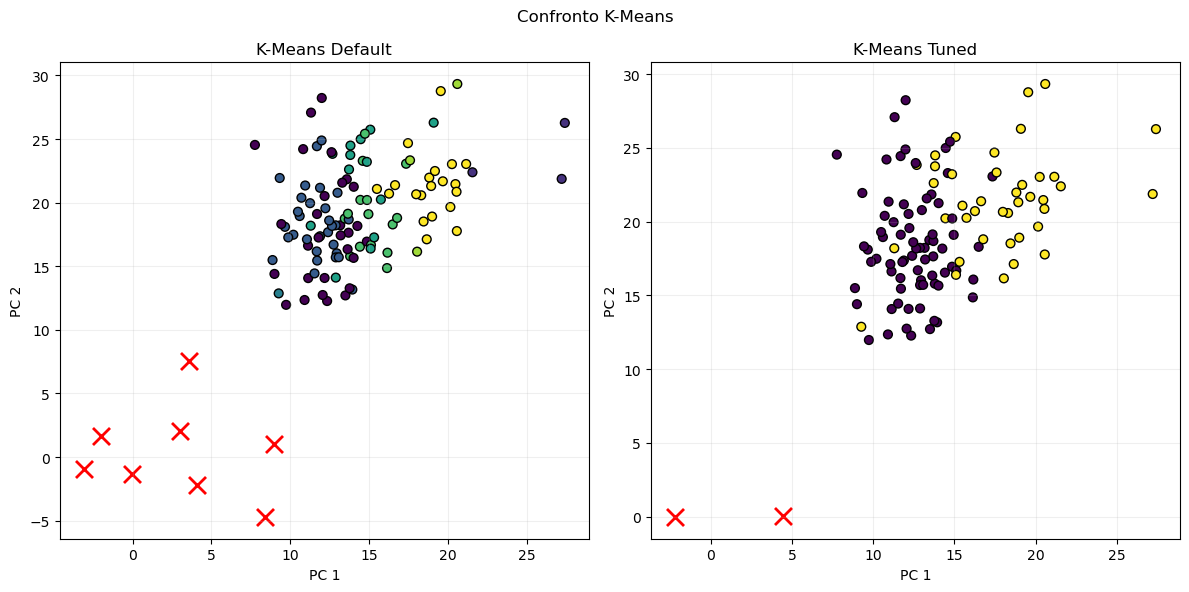

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_clusters(axes[0], X_test_pca,  y_test_pred_default, kmeans_default, "K-Means Default")
plot_clusters(axes[1], X_test_pca,  y_test_pred_tuned, kmeans_best, "K-Means Tuned")
plt.suptitle("Confronto K-Means")
plt.tight_layout()
plt.show()